# Regressão e Previsão

---

### Regressão Linear Simples

A Regressão linear simples modela o relacionamento entre a magnitude de uma variável e aquela de uma segunda - por exemplo, conforme X aumenta, Y também aumenta. Ou conforme X aumenta, Y diminui. A correlação é outro jeito de medir como duas variáveis estão relacionadas. A diferença é que enquanto a correlação mede a força de uma associação entre duas variáveis, a regressão quantifica a natureza do relacionamento.

**Termos-chave**

*Resposta*
- A variável que estamos tentando prever
- Sinônimos: variável dependente, variável Y, alvo, resultado

*Variável independente*
- A variável usada para prever a resposta
- Sinônimos: variável independente, variável X, característica, atributo

*Registro* 
- O vetor dos valores preditor e de resultado para um indivíduo ou caso específico.
- Sinônimos: linha, caso, exemplo

*Intercepto*
- O interceptor da linha de regressão - ou seja, o valor previsto quando X = 0.
- $\beta_0$

*Coeficiente de Regressão
- O declive da linha de regressão s.
- Sinônimos: declive, b1, $\beta_1$, estimativa de parâmetro, peso

*Valores ajustados*
- As estimativas $\hat{Y}$ obtidas da linha de regressão
- Sinônimos: valores previstos

*Resíduo*
- A diferença entre os valores observados e os valores ajustados.
- Sinônimos: erros

*Mínimos quadrados*
- O método de ajustar uma regressão pela minimização da soma dos quadrados dos resíduos.
- Sinônimos: mínimos quadrados ordinários




### Equação de Regressão

A regressão linear simples estima exatamente o quanto Y mudará quando X mudar em uma certa quantidade. Com o coeficiente de correlação, as variáveis X e Y são intercambiáveis. Com a regressão, as variáveis X e Y são intercambiáveis. Com a regressão, estamos tentando prever a variável Y a partir de X usando um relacionamento linear (ou seja, uma linha):

$$
\hat{Y} = \beta_0 + \beta_1 X
$$

Lemos isso como "Y é igual a b1 vezes X, mais uma constante b0". O símbolo b0 é conhecido como o intercepto (ou constante), e o símbolo b1, como o declive para X. Ambos aparecem em resultados do R como coeficientes, apesar de o uso do termo coeficiente ser geralmente reservado para b1. A variável Y é conhecida como resposta ou variável dependente, já que depende de X. A variável X é conhecida como preditora ou variável independente. A comunidade de aprendizado de máquina costuma usar outros termos, chamando Y de alvo e X de vetor de característica.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dados simples de exemplo

# Exemplos de apartamentos: tamanho (m²) e aluguel (R$)
tamanhos = [30, 50, 70, 90, 110]
alugueis = [1500, 2500, 3500, 4500, 5500]

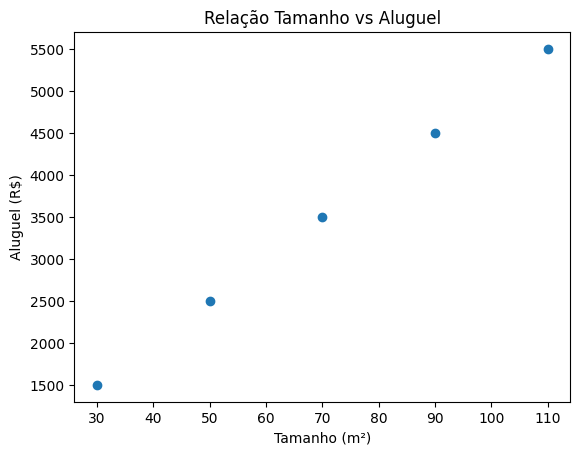

In [3]:
# Visualização dos dados

plt.scatter(tamanhos, alugueis)
plt.xlabel('Tamanho (m²)')
plt.ylabel('Aluguel (R$)')
plt.title('Relação Tamanho vs Aluguel')
plt.show()

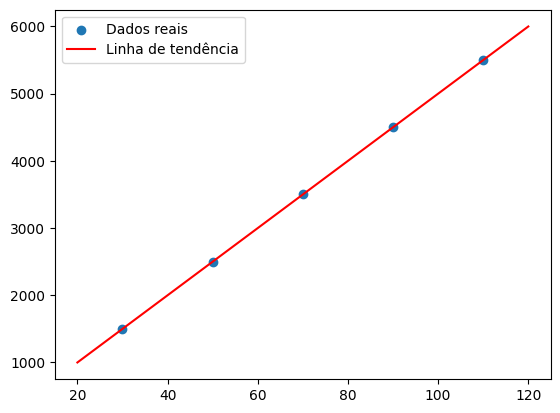

In [4]:
# Adicionar linha de tendência

# Linha representando y = 50x + 0
linha_x = [20, 120]
linha_y = [50 * 20, 50 * 120] # y = 50x
plt.scatter(tamanhos, alugueis, label='Dados reais')
plt.plot(linha_x, linha_y, 'r-', label='Linha de tendência')
plt.legend()
plt.show()

*O Parâmetro de Inclinação (a)*

Problema real: Compreender o que significa dizer que “cada metro quadrado adicional custa R$ 50”.

Solução: O parâmetro a representa a taxa de mudança entre as variáveis.

Como funciona: Se a = 50, significa que cada unidade adicional de x resulta em 50 unidades adicionais de y.


*O Parâmetro de Intercepto (b)*

Problema real: Entender o valor base de um aluguel, independentemente do tamanho.

Solução: O parâmetro b representa o valor inicial quando x é zero.

Como funciona: Se b = 500, significa que há um custo fixo de R$ 500, independentemente do tamanho.

In [5]:
# Exemplo com intercepto

# Nova equação: y = 50x + 500
tamanhos_novo = [30, 50, 70, 90]
alugueis_novo = [50 * t + 500 for t in tamanhos_novo]
print(f"Aluguéis calculados: {alugueis_novo}")

Aluguéis calculados: [2000, 3000, 4000, 5000]


In [6]:
print(f"Custo por m²: R$ 50")
print(f"Custo fixo: R$ 500")
print(f"Apartamento de 60m²: R$ {50 * 60 + 500}")

Custo por m²: R$ 50
Custo fixo: R$ 500
Apartamento de 60m²: R$ 3500


Quando Usar Regressão Linear

A regressão linear é adequada quando:
- Relação proporcional: Uma variável cresce proporcionalmente à outra.
- Tendência constante: A taxa de crescimento não muda drasticamente.
- Dados suficientes: Pelo menos alguns pontos para identificar o padrão.
- Relacionamento claro: Existe lógica no relacionamento entre as variáveis.

Limitações Importantes
- Relações não‑lineares: Não funciona quando a relação é curva.
- Múltiplos fatores: Considera apenas uma variável independente.
- Outliers: Pontos muito distantes podem afetar a linha.
- Extrapolação: Previsões muito além dos dados podem ser imprecisas.

Exemplo 1.

Uma empresa paga R$ 30 por hora trabalhada mais um fixo de R$ 200. Calcule o salário
para 20, 40 e 60 horas.

In [9]:
# Identificar Equação

# Equação: salario = 30 * horas + 200
def calcular_salario(horas):
    return 30 * horas + 200

# Calcular para diferentes valores:
horas_trabalhadas = [20, 40, 60]
for h in horas_trabalhadas:
    salario = calcular_salario(h)
    print(f"{h} horas: R$ {salario}")


20 horas: R$ 800
40 horas: R$ 1400
60 horas: R$ 2000


Exemplo 2.

Uma loja vende produtos com a fórmula: preço = 25 * custo + 15. Explique o significado
de cada número.

In [10]:
# Identificar os parâmetros

# preço = 25 * custo + 15
a = 25 # Inclinação
b = 15 # Intercepto
print(f"Para cada R$ 1 de custo, o preço aumenta R$ {a}")
print(f"Há um custo fixo de R$ {b}")

Para cada R$ 1 de custo, o preço aumenta R$ 25
Há um custo fixo de R$ 15


--- 
### Modelos de Machine Learning

In [11]:
# Preparação dos dados base para reutilização

# Configurar reprodutibilidade
np.random.seed(42)
# Criar dataset de exemplo - apartamentos
m = 100
X = 2 * np.random.rand(m, 1) # Tamanhos dos apartamentos
y = 4 + 3 * X + np.random.randn(m, 1) # Preços com ruído

Estrutura: Features → Modelo (0) → Predição

Os Parâmetros Theta: O Coração do Aprendizado

Conceito de Parâmetros Treináveis

Problema real: Determinar como o modelo “aprende” a fazer predições corretas através do ajuste de
valores numéricos específicos.

Solução: Compreender que os parâmetros theta (0) são valores que o algoritmo ajusta automatica‑
mente para minimizar erros de predição.

In [12]:
# Definição do vetor theta

# Exemplo conceitual de parâmetros
k = 3 # Número de parâmetros para este exemplo
theta = np.array([1.5, 2.3, -0.8])
print(f"Vetor theta: {theta}")

Vetor theta: [ 1.5  2.3 -0.8]


In [13]:
# Features de exemplo para um apartamento
features_exemplo = np.array([75, 2, 1]) # [tamanho, quartos, banheiros]
print(f"Features do apartamento: {features_exemplo}")

Features do apartamento: [75  2  1]


In [14]:
# Multiplicação elemento por elemento
resultado_parcial = features_exemplo * theta
print(f"Resultado parcial: {resultado_parcial}")
resultado_final = np.sum(resultado_parcial)
print(f"Predição final: {resultado_final}")

Resultado parcial: [112.5   4.6  -0.8]
Predição final: 116.3


In [15]:
# Parâmetros da regressão linear simples
theta_0 = 4.0 # Intercepto (valor quando x = 0)
theta_1 = 3.0 # Inclinação (mudança em y por unidade de x)
print(f"Intercepto (0₀): {theta_0}")
print(f"Inclinação (0₁): {theta_1}")

Intercepto (0₀): 4.0
Inclinação (0₁): 3.0


In [16]:
# Calcular predições para diferentes tamanhos
tamanhos = np.array([0.5, 1.0, 1.5, 2.0])
predicoes = theta_0 + theta_1 * tamanhos
print(f"Tamanhos: {tamanhos}")
print(f"Predições: {predicoes}")

Tamanhos: [0.5 1.  1.5 2. ]
Predições: [ 5.5  7.   8.5 10. ]


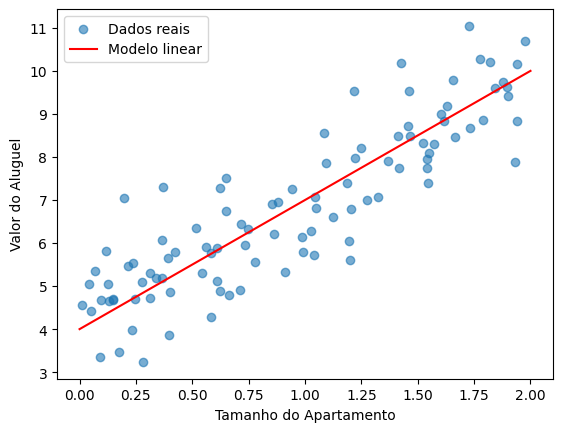

In [18]:
x_linha = np.linspace(0, 2, 100)
y_linha = theta_0 + theta_1 * x_linha

# Plotar dados e modelo
plt.scatter(X, y, alpha=0.6, label='Dados reais')
plt.plot(x_linha, y_linha, 'r-', label='Modelo linear')
plt.xlabel('Tamanho do Apartamento')
plt.ylabel('Valor do Aluguel')
plt.legend()
plt.show()

Interpretação dos Parâmetros

0₀ (Intercepto): Representa o valor base da predição quando todas as features são zero. No contexto
imobiliário, pode ser interpretado como custos fixos independentes do tamanho.


0₁ (Inclinação): Indica quanto a variável dependente muda para cada unidade de mudança na var iável independente. Por exemplo, se 0₁ = 3, cada metro quadrado adicional aumenta o aluguel em 3
unidades monetárias.

A notação ŷ (y‑chapéu) distingue claramente entre valores reais (y) e valores preditos pelo modelo (ŷ).
Esta distinção é fundamental para avaliar a qualidade das predições e identificar onde o modelo está
errando.